In [1]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar


In [2]:
data_dir = '/glade/work/netige/Data/VIKING/OBP'
flist = sorted(glob.glob(data_dir+f'/1_VIKING20X*.nc'))

ds_obp = xr.open_mfdataset(
    flist,
    combine="nested",
    concat_dim="time_counter",   # name in your files
    data_vars="minimal",
    coords="minimal",
    compat="override",
    join="override",
    parallel=True,
    #chunks={"time_counter": -1, "y": -1, "x": -1},  
    chunks={"time_counter": 12, "y": 512, "x": 512}# tweak to taste
    #chunks={"time_counter": -1, "y": 400, "x": 400}
    # engine="h5netcdf",  # optional; often faster/stabler on HPC
)
# Optional: standardize name
ds_obp = ds_obp.rename({"time_counter": "time"})


In [3]:
#modify coordinate names
ds = ds_obp

# wrap/normalize longitudes to [-180, 180]
lon180 = ((ds.nav_lon + 180) % 360) - 180

ds = ds.assign_coords(
    lon=(("y","x"), lon180.values),   # use .values (or .data), not a DataArray
    lat=(("y","x"), ds.nav_lat.values)
)

In [4]:
ds

<xarray.Dataset>
Dimensions:    (y: 2499, x: 2404, deptht: 1, time: 372)
Coordinates:
  * deptht     (deptht) float32 3.047
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
    lon        (y, x) float32 -98.45 -98.4 -98.35 -98.3 ... 32.22 32.27 32.31
    lat        (y, x) float32 -34.01 -34.01 -34.01 -34.01 ... 61.44 61.42 61.41
Dimensions without coordinates: y, x
Data variables:
    nav_lon    (y, x) float32 dask.array<chunksize=(512, 512), meta=np.ndarray>
    nav_lat    (y, x) float32 dask.array<chunksize=(512, 512), meta=np.ndarray>
    sobotpres  (time, y, x) float32 dask.array<chunksize=(12, 512, 512), meta=np.ndarray>
    sossheig   (time, y, x) float32 dask.array<chunksize=(12, 512, 512), meta=np.ndarray>
    sosshpre   (time, y, x) float32 dask.array<chunksize=(12, 512, 512), meta=np.ndarray>
Attributes:
    start_date:        -1
    output_frequency:  N/A
    CONFIG:            N/A
    CASE:              N/A
    history:           Mon Oct 27 21:00:25 2025: ncrcat 1_VIKING20X.L46-KFS00...
    NCO:               netCDF Operators version 5.1.5 (Homepage = http://nco....

In [5]:
# Convert to hPa

def add_cm_var(ds, var="OBP", new_var="OBP_cm"):
    da = ds[var]
    out = (da.astype("float32") * 100  /(1025 * 9.81))
    #out = out * 100
    # copy attrs from the original variable (not from out["OBP"] which doesn't exist)
    out.attrs = dict(da.attrs) if hasattr(da, "attrs") else {}
    out.attrs.update({"units": "cm", "long_name": "Ocean Bottom Pressure (cm)"})
    return ds.assign({new_var: out})

def infer_deg_res(lon2d, lat2d):
    """Infer ~grid spacing (deg) from curvilinear lon/lat."""
    # pick central row/col to avoid edges
    jc = lon2d.shape[0] // 2
    ic = lon2d.shape[1] // 2
    # finite diffs along i (x) and j (y)
    dlon_i = np.abs(np.diff(lon2d[jc, :])).astype(float)
    dlat_j = np.abs(np.diff(lat2d[:, ic])).astype(float)
    # median spacings; guard tiny/NaN
    dx = np.nanmedian(dlon_i[dlon_i > 1e-8])
    dy = np.nanmedian(dlat_j[dlat_j > 1e-8])
    # use min to avoid oversmoothing
    return float(min(dx, dy))

def regular_target_from_bbox(lon2d, lat2d, res=None, pad=0.0):
    """Build regular lat/lon grid covering the 2D bbox at desired res."""
    lon_min = float(np.nanmin(lon2d)); lon_max = float(np.nanmax(lon2d))
    lat_min = float(np.nanmin(lat2d)); lat_max = float(np.nanmax(lat2d))
    if res is None:
        res = infer_deg_res(lon2d, lat2d)
    # pad and snap to grid
    lon_out = np.arange(np.floor(lon_min - pad), np.ceil(lon_max + pad) + res/2, res)
    lat_out = np.arange(np.floor(lat_min - pad), np.ceil(lat_max + pad) + res/2, res)
    return xr.Dataset(
        {"lon": (["lon"], lon_out),
         "lat": (["lat"], lat_out)}
    )

def regrid_curvi_to_regular(da, lon2d, lat2d, res=None, method="bilinear", reuse_weights=False):
    """
    Regrid a curvilinear DataArray (time, y, x) to a regular lat/lon grid.
    Preserves variable name/attrs; works for OBP or SSH alike.
    """
    varname = da.name or "var"

    src = xr.Dataset(
        {"lon": (("y","x"), lon2d), "lat": (("y","x"), lat2d)}
    )
    # put the data inside a dataset using its own name
    src_data = xr.Dataset({varname: da})

    # target regular grid
    tgt = regular_target_from_bbox(lon2d, lat2d, res=res)

    regridder = xe.Regridder(src, tgt, method=method, reuse_weights=reuse_weights)
    out = regridder(src_data)[varname].transpose(..., "lat", "lon")
    out.name = varname
    out.attrs = {**da.attrs, "regridded_with": f"xESMF:{method}"}
    return out

def detrend_per_pixel(da: xr.DataArray, time_dim: str = "time", deg: int = 1) -> xr.DataArray:
    """
    Remove a polynomial trend (default linear) at each pixel along `time_dim`.

    Parameters
    ----------
    da : xr.DataArray
        Input with a time dimension and 2D spatial dims.
    time_dim : str
        Name of the time dimension (default "time").
    deg : int
        Polynomial degree for the trend (1 = linear).

    Returns
    -------
    xr.DataArray
        Same shape as `da`, with the per-pixel trend removed.
    """
    if time_dim not in da.dims:
        raise ValueError(f"`{time_dim}` not found in dims: {da.dims}")

    # Use a numeric index for stable fitting (works with datetime)
    idx = xr.DataArray(
        np.arange(da.sizes[time_dim], dtype="float64"),
        dims=(time_dim,),
        coords={time_dim: da[time_dim]}
    )

    # Temporarily fit on the numeric index (polyfit uses the dim's coordinate values)
    da_idx = da.assign_coords({time_dim: idx})

    # Fit polynomial along time for every pixel (NaNs are skipped)
    pf = da_idx.polyfit(dim=time_dim, deg=deg, skipna=True)  # returns Dataset with "polyfit_coefficients"

    # Evaluate the fitted trend at each time index
    trend_idx = xr.polyval(da_idx[time_dim], pf.polyfit_coefficients)

    # Put original time coordinates back on the trend
    trend = trend_idx.assign_coords({time_dim: da[time_dim]})

    # Subtract trend (preserves attrs)
    detrended = da - trend
    detrended.attrs.update(da.attrs)
    detrended.attrs["detrended"] = f"per-pixel polynomial (deg={deg}) along {time_dim}"
    return detrended

import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

from typing import Optional
import numpy as np
import xarray as xr

def spatial_mean_weighted(
    da: xr.DataArray,
    lat_name: str = "lat",
    lon_name: str = "lon",
    weights: Optional[xr.DataArray] = None,
) -> xr.DataArray:
    """
    Area-weighted spatial mean over (lat, lon) for each time step.
    - Default weights: cos(latitude) (OK for small regional domains).
    - NaN-aware and Dask-friendly.
    """
    # Build static weights if not provided
    if weights is None:
        lat = da[lat_name]
        w_lat = np.cos(np.deg2rad(lat))                    # 1D (lat,)
        # Broadcast to 2D to match (lat, lon)
        w2d, _ = xr.broadcast(w_lat, da.isel({lat_name: slice(None), lon_name: slice(None)}).isel({k:0 for k in da.dims if k not in (lat_name, lon_name)} , drop=True))
        weights = w2d  # dims: (lat, lon)

    # Ensure weights align with spatial dims
    weights = weights.rename({lat_name: lat_name, lon_name: lon_name})
    if set(weights.dims) != {lat_name, lon_name}:
        weights = weights.transpose(lat_name, lon_name)

    # Valid mask (same shape as da)
    valid = xr.where(np.isfinite(da), 1.0, 0.0)

    # Expand weights to all dims of da (e.g., add 'time' by broadcasting)
    w_aligned, _ = xr.broadcast(weights, da.isel({k: 0 for k in da.dims if k not in (lat_name, lon_name)}, drop=True))
    # Broadcast to full shape of da
    w_aligned, _ = xr.broadcast(w_aligned, da)

    # Effective weights ignore NaNs in data
    w_eff = w_aligned * valid

    # Sum over spatial dims
    spatial_dims = [lat_name, lon_name]
    num = (da * w_eff).sum(dim=spatial_dims)
    den = w_eff.sum(dim=spatial_dims)

    return num / den




In [6]:
ds = add_cm_var(ds, "sobotpres", "sobotpres_cm")

ds = add_cm_var(ds, "sosshpre", "sosshpre_cm")

#obp_gs = ds_obp["OBP_hPa"]

In [7]:
obp = ds.sobotpres_cm
ssh_p = ds.sosshpre_cm
ssh = ds.sossheig * 100

In [8]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    obp_regular = regrid_curvi_to_regular(
        obp,
        lon2d=obp.coords["lon"].data,
        lat2d=obp.coords["lat"].data,
        res=None,                 # infer same resolution from the native grid
        method="bilinear",        # or 'nearest_s2d' if you want exact nearest
        reuse_weights=False)

    ssh_p_regular = regrid_curvi_to_regular(
        ssh_p,
        lon2d=ssh_p.coords["lon"].data,
        lat2d=ssh_p.coords["lat"].data,
        res=None,                 # infer same resolution from the native grid
        method="bilinear",        # or 'nearest_s2d' if you want exact nearest
        reuse_weights=False)

    ssh_regular = regrid_curvi_to_regular(
        ssh,
        lon2d=ssh_p.coords["lon"].data,
        lat2d=ssh_p.coords["lat"].data,
        res=None,                 # infer same resolution from the native grid
        method="bilinear",        # or 'nearest_s2d' if you want exact nearest
        reuse_weights=False)

#print(obp_gs_regular)

#obp_gs_regular = obp_gs_regular
#obp_gs_regular     = subset_box(obp_gs_regular, lon_min=-85, lon_max=-43, lat_min=25, lat_max=50)

In [9]:
obp_regular = obp_regular.sel(
    lat=slice(-33.5, 65),
    lon=slice(-98, 20)
)

ssh_p_regular = ssh_p_regular.sel(
    lat=slice(-33.5, 65),
    lon=slice(-98, 20)
)

ssh_regular = ssh_regular.sel(
    lat=slice(-33.5, 65),
    lon=slice(-98, 20)
)

In [10]:
obp_regular = obp_regular.chunk({"time": -1, "lat": -1, "lon": -1})
ssh_p_regular = ssh_p_regular.chunk({"time": -1, "lat": -1, "lon": -1})
ssh_regular = ssh_regular.chunk({"time": -1, "lat": -1, "lon": -1})

In [11]:
# Optional: modest rechunk along time
#obp_regular  = obp_regular.chunk({"time": -1})
#ssh_p_regular = ssh_p_regular.chunk({"time": -1})

obp_mean_ts   = spatial_mean_weighted(obp_regular)       # (time,)
ssh_p_mean_ts = spatial_mean_weighted(ssh_p_regular)     # (time,)
ssh_mean_ts = spatial_mean_weighted(ssh_regular) 

# If you have an exact cell-area field:
# area_da: xr.DataArray with dims (lat, lon), units m^2
# obp_mean_ts = spatial_mean_weighted(obp_regular, weights=area_da)


In [12]:
obp_regular = obp_regular.chunk({"time": -1, "lat": -1, "lon": -1})
ssh_p_regular = ssh_p_regular.chunk({"time": -1, "lat": -1, "lon": -1})
ssh_regular = ssh_regular.chunk({"time": -1, "lat": -1, "lon": -1})

In [13]:
obp_rm = obp_regular - obp_mean_ts
ssh_p_rm = ssh_p_regular - ssh_p_mean_ts
ssh_rm = ssh_regular - ssh_mean_ts

In [14]:
obp_rm_dt = detrend_per_pixel(obp_rm)
ssh_p_rm_dt = detrend_per_pixel(ssh_p_rm)
ssh_rm_dt = detrend_per_pixel(ssh_rm)
#obp_dt = detrend_per_pixel(obp_regular)
#ssh_p_dt = detrend_per_pixel(ssh_p_regular)

In [15]:
print(obp_rm_dt, ssh_p_rm_dt, ssh_rm_dt)

<xarray.DataArray (time: 372, lat: 2267, lon: 2715)>
dask.array<sub, shape=(372, 2267, 2715), dtype=float64, chunksize=(372, 2267, 2715), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time <xarray.DataArray (time: 372, lat: 2267, lon: 2715)>
dask.array<sub, shape=(372, 2267, 2715), dtype=float64, chunksize=(372, 2267, 2715), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99
Attributes:
    detrended:  per-pixel polynomial (deg=1) along time <xarray.DataArray (time: 372, lat: 2267, lon: 27

In [16]:
import xarray as xr
from dask.diagnostics import ProgressBar

# Ensure clear variable names in the file (optional if already named as below)
obp_rm_dt_named   = obp_rm_dt.rename("obp_rm_dt")
ssh_p_rm_dt_named = ssh_p_rm_dt.rename("ssh_p_rm_dt")
ssh_rm_dt_named   = ssh_rm_dt.rename("ssh_rm_dt")

# Assemble a single dataset (no .data so Dask remains lazy)
ds_out = xr.Dataset(
    data_vars={
        "obp_rm_dt":   obp_rm_dt_named,   # (time, lat, lon)
        "ssh_p_rm_dt": ssh_p_rm_dt_named, # (time, lat, lon)
        "ssh_rm_dt":   ssh_rm_dt_named,   # (time, lat, lon)
    },
    attrs={
        "title": "Mean-removed & detrended OBP and SSH variants",
        "history": "Created with xarray.to_netcdf (chunked + compressed)",
        "Conventions": "CF-1.8",
    }
)

# Optional: add/standardize metadata
ds_out["lat"].attrs.update({"standard_name": "latitude",  "units": "degrees_north"})
ds_out["lon"].attrs.update({"standard_name": "longitude", "units": "degrees_east"})
ds_out["obp_rm_dt"].attrs.update({"long_name": "OBP mean-removed & detrended", "units": "cm"})
ds_out["ssh_p_rm_dt"].attrs.update({"long_name": "SSH pressure-equivalent mean-removed & detrended", "units": "cm"})
ds_out["ssh_rm_dt"].attrs.update({"long_name": "SSH (height) mean-removed & detrended", "units": "m"})

# Compression / dtype (adjust complevel as desired)
comp_f32 = dict(zlib=True, complevel=4, dtype="float32")
enc = {
    "obp_rm_dt":   comp_f32,
    "ssh_p_rm_dt": comp_f32,
    # keep SSH height in meters as float32 too, or use float64 if you prefer
    "ssh_rm_dt":   comp_f32,
    "time": {"dtype": "int64"},  # let engine encode CF time units
    "lat":  {"dtype": "float64"},
    "lon":  {"dtype": "float64"},
}

# (Optional) write preferred on-disk chunk sizes:
# enc["obp_rm_dt"]["chunksizes"]   = (12, 256, 256)
# enc["ssh_p_rm_dt"]["chunksizes"] = (12, 256, 256)
# enc["ssh_rm_dt"]["chunksizes"]   = (12, 256, 256)

outfile = "/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc"
with ProgressBar():
    ds_out.to_netcdf(outfile, engine="h5netcdf", mode="w", encoding=enc, compute=True)

print(f"Wrote {outfile}")


[########################################] | 100% Completed | 43m 8ss
Wrote /glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc


In [4]:
ds_out.obp_rm_dt_named

NameError: name 'ds_out' is not defined

In [15]:
ssh_obp_dif        = ssh_rm_dt - obp_rm_dt
ssh_ssh_p_dif      = ssh_rm_dt - ssh_p_rm_dt
ssh_obp_dif_var    = ssh_obp_dif.var(dim='time')
ssh_ssh_p_dif_var  = ssh_ssh_p_dif.var(dim='time')
ssh_var            = ssh_rm_dt.var(dim = 'time')

In [17]:
print(ssh_obp_dif_var, ssh_ssh_p_dif_var, ssh_var)

<xarray.DataArray (lat: 2267, lon: 2715)>
dask.array<moment_agg-aggregate, shape=(2267, 2715), dtype=float64, chunksize=(87, 512), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99 <xarray.DataArray (lat: 2267, lon: 2715)>
dask.array<moment_agg-aggregate, shape=(2267, 2715), dtype=float64, chunksize=(87, 512), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99 <xarray.DataArray (lat: 2267, lon: 2715)>
dask.array<moment_agg-aggregate, shape=(2267, 2715), dtype=float64, chunksize=(87, 512), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99


In [16]:
import xarray as xr
from dask.diagnostics import ProgressBar

# Make sure each variable has a clear name
da1 = ssh_obp_dif_var.rename("ssh_obp_dif_var")     # var(SSH − OBP)
da2 = ssh_ssh_p_dif_var.rename("ssh_ssh_p_dif_var") # var(SSH − SSH_p)
da3 = ssh_var.rename("ssh_var")                     # var(SSH)

# Bundle into a single Dataset (keeps Dask laziness; no .data)
ds_out = xr.Dataset(
    data_vars={
        "ssh_obp_dif_var":  da1,
        "ssh_ssh_p_dif_var": da2,
        "ssh_var":           da3,
    },
    coords={
        "lat": da1["lat"],
        "lon": da1["lon"],
    },
    attrs={
        "title": "Bottom-pressure / SSH variance diagnostics",
        "history": "Created via xarray.to_netcdf (chunked + compressed)",
        "Conventions": "CF-1.8",
    },
)

# Optional metadata
ds_out["lat"].attrs.update({"standard_name": "latitude",  "units": "degrees_north"})
ds_out["lon"].attrs.update({"standard_name": "longitude", "units": "degrees_east"})
ds_out["ssh_obp_dif_var"].attrs.update({"long_name": "Temporal variance of (SSH − OBP)",   "units": "cm^2"})
ds_out["ssh_ssh_p_dif_var"].attrs.update({"long_name": "Temporal variance of (SSH − SSH_p)","units": "cm^2"})
ds_out["ssh_var"].attrs.update({"long_name": "Temporal variance of SSH",                    "units": "cm^2"})

# Compression / dtype (tune complevel and chunksizes to your workflow)
comp_f32 = dict(zlib=True, complevel=4, dtype="float32")
enc = {
    "ssh_obp_dif_var":  comp_f32,
    "ssh_ssh_p_dif_var": comp_f32,
    "ssh_var":           comp_f32,
    "lat": {"dtype": "float64"},
    "lon": {"dtype": "float64"},
}
# If you want on-disk chunking, uncomment and set sensible sizes:
# enc["ssh_obp_dif_var"]["chunksizes"]  = (256, 256)
# enc["ssh_ssh_p_dif_var"]["chunksizes"] = (256, 256)
# enc["ssh_var"]["chunksizes"]          = (256, 256)

outfile = "/glade/work/netige/Data/VIKING/ssh_obp_variance_products.nc"
with ProgressBar():
    ds_out.to_netcdf(outfile, engine="h5netcdf", mode="w", encoding=enc, compute=True)

print(f"Wrote {outfile}")


[#######                                 ] | 19% Completed | 305.43 s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[####################                    ] | 50% Completed | 15m 0sss

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[####################################### ] | 98% Completed | 29m 16s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [21]:
x = (obp_rm_dt -ssh_p_rm_dt)
y = obp_rm_dt

var_x = x.var(dim = 'time')
var_y = y.var(dim = 'time')

PVE = (1 - (var_x/var_y)) * 100



In [ ]:
1+1

In [20]:
with ProgressBar():
    PVE.persist()

[                                        ] | 0% Completed | 1.00 s ms


KeyboardInterrupt: 

In [22]:
with ProgressBar():
    PVE = PVE.to_dataset(name='PVE').persist()
    PVE.to_netcdf('/glade/work/netige/Data/VIKING/OBP_PVE_by_SSH.nc', format="NETCDF4", engine="netcdf4")
    #ds_out = ssh_p_var.to_dataset(name='ssh_p_var')
    #ds_out.to_netcdf('/glade/work/netige/Data/VIKING/ssh_obp_var_VIKING.nc', format="NETCDF4", engine="netcdf4")


[########################################] | 100% Completed | 24m 50s
[########################################] | 100% Completed | 295.59 ms


In [16]:
PVE.plot()


KeyboardInterrupt



In [27]:
obp_var = obp_regular.var(dim = 'time')
ssh_p_var = ssh_p_regular.var(dim = 'time')
obp_var_rm = obp_rm.var(dim = 'time')
ssh_p_var_rm = ssh_p_rm.var(dim = 'time')
obp_var_dt = obp_dt.var(dim = 'time')
ssh_p_var_dt = ssh_p_dt.var(dim = 'time')
obp_var_rm_dt = obp_rm_dt.var(dim = 'time')
ssh_p_var_rm_dt = ssh_p_rm_dt.var(dim = 'time')

In [14]:
print(obp_var, ssh_p_var, obp_var_rm, ssh_p_var_rm,
      obp_var_dt, ssh_p_var_dt, obp_var_rm_dt, ssh_p_var_rm_dt)

<xarray.DataArray 'OBP_hPa' (lat: 2267, lon: 2715)>
dask.array<moment_agg-aggregate, shape=(2267, 2715), dtype=float32, chunksize=(2267, 2715), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99 <xarray.DataArray 'OBP_hPa' (lat: 2267, lon: 2715)>
dask.array<moment_agg-aggregate, shape=(2267, 2715), dtype=float32, chunksize=(2267, 2715), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99 <xarray.DataArray (lat: 2267, lon: 2715)>
dask.array<moment_agg-aggregate, shape=(2267, 2715), dtype=float64, chunksize=(2267, 2715), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -97.96 -97.91 -97.87 -97.83 ... 19.89 19.93 19.98
  * lat      (lat) float64 -33.48 -33.44 -33.39 -33.35 ... 64.9 64.94 64.99 <xarr

In [16]:
import xarray as xr
from dask.diagnostics import ProgressBar

# Ensure variable names you want in the file
obp_mean = obp_mean_ts.rename("obp_mean")
ssh_mean = ssh_p_mean_ts.rename("ssh_p_mean")
obp_var2d = obp_var.rename("obp_var")
ssh_var2d = ssh_p_var.rename("ssh_p_var")

# Build a single Dataset with shared coordinates
ds_out = xr.Dataset(
    data_vars={
        "obp_var": (("lat","lon"), obp_var.data,
                    {"long_name": "Temporal variance of OBP",
                     "units": (obp_var.attrs.get("units","cm") + "^2") if obp_var.attrs.get("units") else "cm^2"}),
        "ssh_p_var": (("lat","lon"), ssh_p_var.data,
                      {"long_name": "Temporal variance of SSH (pressure-equivalent)",
                       "units": (ssh_p_var.attrs.get("units","cm") + "^2") if ssh_p_var.attrs.get("units") else "cm^2"}),
        "obp_var_rm": (("lat","lon"), obp_var_rm.data,
                    {"long_name": "Temporal variance of OBP (mean removed)",
                     "units": (obp_var_rm.attrs.get("units","cm") + "^2") if obp_var_rm.attrs.get("units") else "cm^2"}),
        "ssh_p_var_rm": (("lat","lon"), ssh_p_var_rm.data,
                      {"long_name": "Temporal variance of SSH (pressure-equivalent) (mean removed)",
                       "units": (ssh_p_var_rm.attrs.get("units","cm") + "^2") if ssh_p_var_rm.attrs.get("units") else "cm^2"}),
        "obp_var_dt": (("lat","lon"), obp_var_dt.data,
                    {"long_name": "Temporal variance of OBP (trend removed)",
                     "units": (obp_var_dt.attrs.get("units","cm") + "^2") if obp_var_dt.attrs.get("units") else "cm^2"}),
        "ssh_p_var_dt": (("lat","lon"), ssh_p_var_dt.data,
                      {"long_name": "Temporal variance of SSH (pressure-equivalent) (trend removed)",
                       "units": (ssh_p_var_dt.attrs.get("units","cm") + "^2") if ssh_p_var_dt.attrs.get("units") else "cm^2"}),
        "obp_var_rm_dt": (("lat","lon"), obp_var_rm_dt.data,
                    {"long_name": "Temporal variance of OBP (trend & mean removed)",
                     "units": (obp_var_rm_dt.attrs.get("units","cm") + "^2") if obp_var_rm_dt.attrs.get("units") else "cm^2"}),
        "ssh_p_var_rm_dt": (("lat","lon"), ssh_p_var_rm_dt.data,
                      {"long_name": "Temporal variance of SSH (pressure-equivalent) (trend & mean removed)",
                       "units": (ssh_p_var_rm_dt.attrs.get("units","cm") + "^2") if ssh_p_var_rm_dt.attrs.get("units") else "cm^2"}),
    },
    coords={
        "lat":  obp_var["lat"],
        "lon":  obp_var["lon"],
    },
    attrs={
        "title": "OBP & SSH summary statistics",
        "history": "Created by xarray.to_netcdf with Dask compression",
        "Conventions": "CF-1.8"
    }
)

# Optional: give coordinates CF-style metadata
ds_out["lat"].attrs.update({"standard_name": "latitude", "units": "degrees_north"})
ds_out["lon"].attrs.update({"standard_name": "longitude", "units": "degrees_east"})


# Compression / dtype settings (tune complevel as you like)
comp_float32 = dict(zlib=True, complevel=4, dtype="float32")
enc = {
    "obp_var":   comp_float32,
    "ssh_p_var": comp_float32,
    "obp_var_rm":    comp_float32,
    "ssh_p_var_rm":  comp_float32,
    "obp_var_dt":   comp_float32,
    "ssh_p_var_dt": comp_float32,
    "obp_var_rm_dt":    comp_float32,
    "ssh_p_var_rm_dt":  comp_float32,
    # coords typically left uncompressed; keep as double for precision
    "lat": {"dtype": "float64"},
    "lon": {"dtype": "float64"},
}

# Write to disk (Dask-aware). h5netcdf is often faster/more robust on HPC systems.
outfile = "/glade/work/netige/Data/VIKING/obp_ssh_summary2.nc"
with ProgressBar():
    ds_out.to_netcdf(outfile, mode="w", engine="h5netcdf", encoding=enc, compute=True)

print(f"Wrote {outfile}")


[########################################] | 100% Completed | 32m 7ss
Wrote /glade/work/netige/Data/VIKING/obp_ssh_summary2.nc


In [4]:
ds_obp = add_cm_var(ds_obp, "sobotpres", "sobotpres_cm")

ds_obp = add_cm_var(ds_obp, "sosshpre", "sosshpre_cm")

#obp_gs = ds_obp["OBP_hPa"]

In [5]:
#ds_obp = ds_obp.chunk({'time': -1, 'y': -1, 'x': -1})
ds_obp.sossheig

<xarray.DataArray 'sossheig' (time: 372, y: 2499, x: 2404)>
dask.array<concatenate, shape=(372, 2499, 2404), dtype=float32, chunksize=(12, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Dimensions without coordinates: y, x
Attributes:
    units:             m
    valid_min:         -10.0
    valid_max:         10.0
    long_name:         Sea Surface Height
    short_name:        sossheig
    iweight:           1
    online_operation:  N/A
    axis:              TYX
    savelog10:         0.0
    cell_methods:      time_counter: mean

### Compute PVE

1. Compute variance of SSH
2. Compute variance of OBP
3. x = (OBP_var - SSH_var)
4. y = x/OBP_var

In [15]:
ds_obp.sobotpres_cm.isel(time=0).plot()

KeyboardInterrupt: 

In [ ]:
ds_obp.sosshpre_cm.isel(time=0).plot()

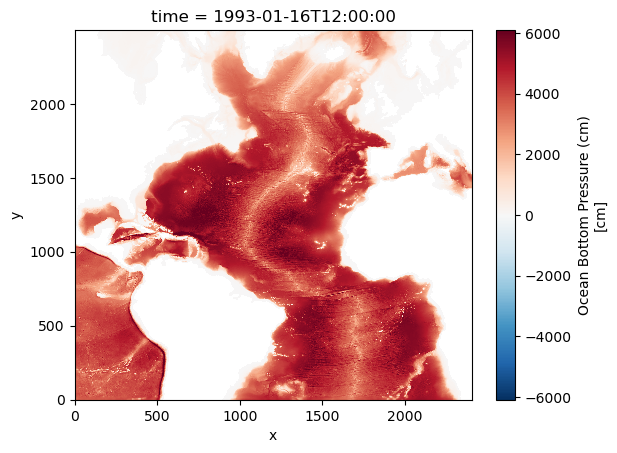

In [32]:
ds_obp.OBP_m.isel(time=0).plot()

In [15]:
ds_obp.sossheig

<xarray.DataArray 'sossheig' (time: 372, y: 2499, x: 2404)>
dask.array<concatenate, shape=(372, 2499, 2404), dtype=float32, chunksize=(12, 400, 400), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
Dimensions without coordinates: y, x
Attributes:
    units:             m
    valid_min:         -10.0
    valid_max:         10.0
    long_name:         Sea Surface Height
    short_name:        sossheig
    iweight:           1
    online_operation:  N/A
    axis:              TYX
    savelog10:         0.0
    cell_methods:      time_counter: mean

In [29]:
obp_var = ds_obp.sosshpre_cm.var(dim = 'time')

AttributeError: 'Dataset' object has no attribute 'sosshpre_cm'

In [7]:
ssh_p_var = ds_obp.sobotpres_cm.var(dim = 'time')

In [15]:
PVE = (1 - ((obp_var - ssh_p_var)/obp_var))*100

In [8]:
PVE = (ssh_p_var/obp_var) * 100

In [18]:
x = obp_var - ssh_var
y = obp_var

In [19]:
PVE = (1 - (x/y))*100

In [28]:
x = obp_var - ssh_p_var
y = obp_var

In [30]:
PVE2 = (1 - (x/y))*100

In [ ]:
with ProgressBar():
    ds_out = PVE.to_dataset(name='PVE')
    ds_out.to_netcdf('/glade/work/netige/Data/VIKING/OBP_PVE_by_SSH.nc', format="NETCDF4", engine="netcdf4")


[###################                     ] | 47% Completed | 523.73 s

In [13]:
with ProgressBar():
    ds_out = obp_var.to_dataset(name='obp_var')
    ds_out.to_netcdf('/glade/work/netige/Data/VIKING/obp_var_VIKING.nc', format="NETCDF4", engine="netcdf4")
    ds_out = ssh_p_var.to_dataset(name='ssh_p_var')
    ds_out.to_netcdf('/glade/work/netige/Data/VIKING/ssh_obp_var_VIKING.nc', format="NETCDF4", engine="netcdf4")


[########################################] | 100% Completed | 325.62 s
[########################################] | 100% Completed | 393.84 s


In [28]:
with ProgressBar():
    ds_out = obp_var.to_dataset(name='obp_var')
    ds_out.to_netcdf('/glade/work/netige/Data/VIKING/obp_var_VIKING2.nc', format="NETCDF4", engine="netcdf4")
    ds_out = ssh_p_var.to_dataset(name='ssh_p_var')
    ds_out.to_netcdf('/glade/work/netige/Data/VIKING/ssh_obp_var_VIKING2.nc', format="NETCDF4", engine="netcdf4")


[########################################] | 100% Completed | 25m 36s
[#########                               ] | 22% Completed | 342.72 s


KeyboardInterrupt: 